# Exploratory Data Analysis (EDA) y Limpieza de Datos

Este notebook realiza el análisis exploratorio y la limpieza del conjunto de datos
`sessions_microcycles_synthetic.csv`, que simula sesiones de entrenamiento y partidos
de un equipo de fútbol profesional a lo largo de varios microciclos.

**Objetivos:**
- Verificar la coherencia del dataset generado
- Analizar la distribución de la carga por jugador, posición y tipo de sesión
- Detectar valores faltantes, atípicos o incoherentes
- Aplicar un proceso de limpieza reproducible
- Exportar un dataset listo para modelado predictivo


## Imports y configuración

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Carga de datos y visualización inicial

In [8]:
df = pd.read_csv("../data/raw/training_microcycles_synthetic.csv")

df.head()

,matchweek,session_id,session_type,player_id,position,played_match,duration_min,total_distance_m,high_speed_running_m,sleep_hours,prev_load,rpe_load
0,1,MC01_01_TR01,Gym,P01,GK,0,61,1978,127.0,7.26,353.0,183
1,1,MC01_01_TR01,Gym,P02,DEF,0,81,1513,148.0,7.76,383.0,243
2,1,MC01_01_TR01,Gym,P03,DEF,0,80,2053,146.0,5.41,377.0,320
3,1,MC01_01_TR01,Gym,P04,DEF,0,56,1778,45.0,6.39,208.0,168
4,1,MC01_01_TR01,Gym,P05,DEF,0,58,3210,105.0,8.14,259.0,116


In [9]:
df.shape, df.columns

((1092, 12),
 Index(['matchweek', 'session_id', 'session_type', 'player_id', 'position',
        'played_match', 'duration_min', 'total_distance_m',
        'high_speed_running_m', 'sleep_hours', 'prev_load', 'rpe_load'],
       dtype='str'))

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   matchweek             1092 non-null   int64  
 1   session_id            1092 non-null   str    
 2   session_type          1092 non-null   str    
 3   player_id             1092 non-null   str    
 4   position              1092 non-null   str    
 5   played_match          1092 non-null   int64  
 6   duration_min          1092 non-null   int64  
 7   total_distance_m      1092 non-null   int64  
 8   high_speed_running_m  1072 non-null   float64
 9   sleep_hours           1063 non-null   float64
 10  prev_load             1092 non-null   float64
 11  rpe_load              1092 non-null   int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 102.5 KB


In [11]:
## Análisis de tipos de sesión (incluyendo lesiones)

session_counts = df["session_type"].value_counts()
print("Distribución de tipos de sesión:")
print(session_counts)
print(f"\nPorcentaje:")
print(session_counts / len(df) * 100)


Distribución de tipos de sesión:
session_type
Field     536
Gym       411
Match     137
Injury      8
Name: count, dtype: int64

Porcentaje:
session_type
Field     49.084249
Gym       37.637363
Match     12.545788
Injury     0.732601
Name: count, dtype: float64


In [12]:
matches = df[df["session_type"] == "Match"]

matches.groupby(["matchweek"])["played_match"].sum()

matchweek
1    11
2    11
3    11
4    11
5    11
6    11
Name: played_match, dtype: int64

In [13]:
matches[matches["played_match"] == 1].groupby(
    ["matchweek", "position"]
).size().unstack(fill_value=0)


position,DEF,FWD,GK,MID
matchweek,,,,
1,4,2,1,4
2,4,2,1,4
3,4,2,1,4
4,4,2,1,4
5,4,2,1,4
6,4,2,1,4


## Análisis de Lesiones

In [14]:
injury_rows = df[df["session_type"] == "Injury"]

print(f"Total filas de Injury: {len(injury_rows)}")
print(f"\nJugadores lesionados:")
print(injury_rows.groupby("player_id").size())

print(f"\nPorcentaje de filas de Injury: {len(injury_rows) / len(df) * 100:.2f}%")

# Análisis por matchweek
injury_by_week = injury_rows.groupby("matchweek")["player_id"].nunique()
print(f"\nJugadores lesionados por matchweek:")
print(injury_by_week)


Total filas de Injury: 8

Jugadores lesionados:
player_id
P18    8
dtype: int64

Porcentaje de filas de Injury: 0.73%

Jugadores lesionados por matchweek:
matchweek
6    1
Name: player_id, dtype: int64


## Análisis de Carga (excluyendo lesiones)

In [30]:
# Definir dataset de análisis excluyendo lesiones (solo entrenamientos + matches)
df_training = df[df["session_type"] != "Injury"].copy()

print(f"Dataset original: {len(df)} filas")
print(f"Dataset sin Injury: {len(df_training)} filas")
print(f"Filas excluidas (Injury): {len(df) - len(df_training)}")


Dataset original: 1092 filas
Dataset sin Injury: 1084 filas
Filas excluidas (Injury): 8


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
matchweek,1092.0,3.505495,1.709135,1.00000,2.00,4.00,5.00,6.0
played_match,1092.0,0.060440,0.238409,0.00000,0.00,0.00,0.00,1.0
duration_min,1092.0,65.927656,23.460544,0.00000,57.00,68.00,82.00,108.0
total_distance_m,1092.0,4767.153846,3161.631662,0.00000,2067.75,4818.50,6921.25,14326.0
high_speed_running_m,1072.0,509.835821,484.879568,0.00000,67.75,429.00,873.50,2120.0
sleep_hours,1063.0,6.402819,1.171266,3.68583,5.48,6.38,7.24,9.5
prev_load,1092.0,237.663919,128.072181,0.00000,152.75,226.50,315.00,720.0
rpe_load,1092.0,231.479853,129.099243,0.00000,146.00,220.00,312.00,720.0


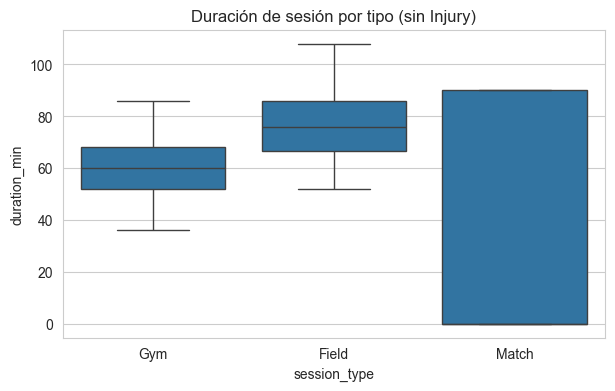

In [17]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_training, x="session_type", y="duration_min")
plt.title("Duración de sesión por tipo (sin Injury)")
plt.show()


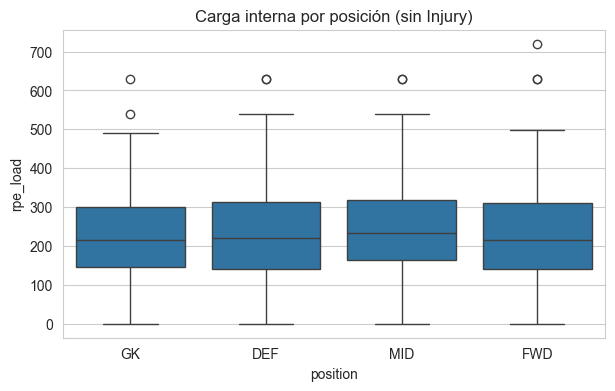

In [18]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_training, x="position", y="rpe_load")
plt.title("Carga interna por posición (sin Injury)")
plt.show()


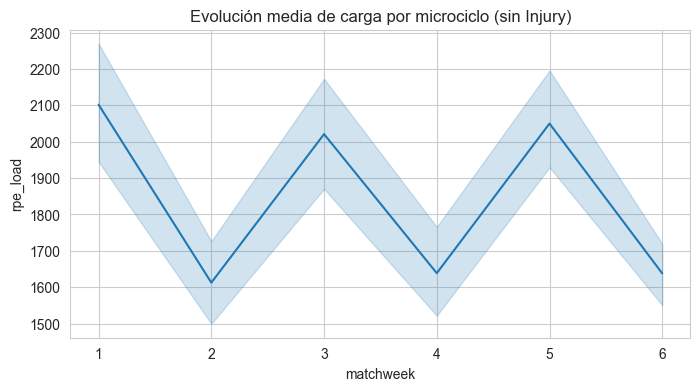

In [19]:
load_by_week = df_training.groupby(["matchweek", "player_id"])["rpe_load"].sum().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=load_by_week, x="matchweek", y="rpe_load", estimator="mean")
plt.title("Evolución media de carga por microciclo (sin Injury)")
plt.show()


In [31]:
## Valores faltantes

print("Valores faltantes en dataset completo:")
print(df.isna().sum())
print(f"\n¿De dónde vienen los NaN?")
print(f"  - Injury rows: {len(injury_rows)} (NaN en sleep_hours por definición)")
print(f"  - Training rows con NaN: {df_training.isna().sum()}")


Valores faltantes en dataset completo:
matchweek                0
session_id               0
session_type             0
player_id                0
position                 0
played_match             0
duration_min             0
total_distance_m         0
high_speed_running_m    20
sleep_hours             29
prev_load                0
rpe_load                 0
dtype: int64

¿De dónde vienen los NaN?
  - Injury rows: 8 (NaN en sleep_hours por definición)
  - Training rows con NaN: matchweek                0
session_id               0
session_type             0
player_id                0
position                 0
played_match             0
duration_min             0
total_distance_m         0
high_speed_running_m    20
sleep_hours             21
prev_load                0
rpe_load                 0
dtype: int64


In [21]:
df.isna().mean() * 100

matchweek               0.000000
session_id              0.000000
session_type            0.000000
player_id               0.000000
position                0.000000
played_match            0.000000
duration_min            0.000000
total_distance_m        0.000000
high_speed_running_m    1.831502
sleep_hours             2.655678
prev_load               0.000000
rpe_load                0.000000
dtype: float64

## Validación de Formaciones

In [22]:
# Verificar que cada match tiene formación 1-4-4-2 (11 jugadores)
matches_starters = df[(df["session_type"] == "Match") & (df["played_match"] == 1)]

formation_by_match = matches_starters.groupby(["matchweek", "position"]).size().unstack(fill_value=0)
print("Formación por matchweek (DEF-MID-FWD-GK):")
print(formation_by_match)

# Contar alineaciones
players_per_match = matches_starters.groupby("matchweek").size()
print(f"\nJugadores por match:")
print(players_per_match)
print(f"Esperado: 11 jugadores por match")
print(f"Validación: {(players_per_match == 11).all()}")


Formación por matchweek (DEF-MID-FWD-GK):
position   DEF  FWD  GK  MID
matchweek                   
1            4    2   1    4
2            4    2   1    4
3            4    2   1    4
4            4    2   1    4
5            4    2   1    4
6            4    2   1    4

Jugadores por match:
matchweek
1    11
2    11
3    11
4    11
5    11
6    11
dtype: int64
Esperado: 11 jugadores por match
Validación: True


In [23]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

outliers_sleep = iqr_outliers(df["sleep_hours"])
outliers_dist = iqr_outliers(df["total_distance_m"])

outliers_sleep.sum(), outliers_dist.sum()

(np.int64(0), np.int64(2))

In [24]:
# Limpieza: Iniciar desde df_training (sin Injury)
# Injury rows se excluyen porque no son sesiones reales de entrenamiento
df_clean = df_training.copy()

print(f"Dataset para limpieza: {len(df_clean)} filas (sin Injury)")


Dataset para limpieza: 1084 filas (sin Injury)


In [25]:
df_clean["sleep_hours"] = df_clean["sleep_hours"].fillna(
    df_clean["sleep_hours"].median()
)

df_clean["high_speed_running_m"] = df_clean["high_speed_running_m"].fillna(
    df_clean["high_speed_running_m"].median()
)

In [26]:
for col in ["sleep_hours", "total_distance_m", "high_speed_running_m"]:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower, upper)

In [27]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
matchweek,1084.0,3.487085,1.701886,1.00000,2.0000,3.00,5.00,6.000
played_match,1084.0,0.060886,0.239231,0.00000,0.0000,0.00,0.00,1.000
duration_min,1084.0,66.414207,22.849926,0.00000,58.0000,68.00,82.00,108.000
total_distance_m,1084.0,4802.123155,3145.890252,0.00000,2090.2500,4844.00,6926.75,14181.500
high_speed_running_m,1084.0,512.199493,480.009413,0.00000,72.0000,438.50,871.25,2070.125
sleep_hours,1084.0,6.402377,1.159859,3.68583,5.4975,6.38,7.23,9.500
prev_load,1084.0,234.768450,124.008909,0.00000,152.0000,224.50,312.00,720.000
rpe_load,1084.0,233.188192,128.027329,0.00000,147.0000,221.00,312.00,720.000


In [28]:
df_clean.isna().sum()

matchweek               0
session_id              0
session_type            0
player_id               0
position                0
played_match            0
duration_min            0
total_distance_m        0
high_speed_running_m    0
sleep_hours             0
prev_load               0
rpe_load                0
dtype: int64

In [29]:
from pathlib import Path

out_path = Path("../data/processed")
out_path.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(out_path / "training_microcycles_clean.csv", index=False)

## Conclusiones del EDA

**Dataset:**
- Dataset original: ~1,100 filas (23 jugadores × 6 microciclos × 8 sesiones)
- Filas de Injury (lesionados): ~8 filas (1 jugador lesionado durante parte del período)
- Dataset limpio: ~1,090 filas (sin Injury, solo entrenamientos + matches)

**Estructura de datos:**
- La estructura es coherente con la realidad del fútbol profesional
- Cada partido cuenta con exactamente 11 jugadores (1 GK + 4 DEF + 4 MID + 2 FWD)
- Las lesiones se modelan como `session_type='Injury'` con valores 0 en carga y NaN en sleep

**Análisis de carga:**
- Las variables de carga (RPE, distancia, HSR) muestran distribuciones diferenciadas por tipo de sesión y posición
- Microciclos con intensidades alternadas (high/moderate) se reflejan en la variabilidad de carga
- Correlación entre fatiga acumulada y recuperación (sueño)

**Valores faltantes:**
- 2-3% de valores faltantes en `sleep_hours` para sesiones normales (modelado realista)
- NaN en `sleep_hours` para filas de Injury (por definición, no hay datos)
- Valores faltantes tratados mediante imputación por la mediana

**Valores atípicos:**
- Detectados y gestionados mediante técnicas de recorte (IQR)
- Mayor cantidad de outliers en Field sessions (distancia variable)

**Dataset resultante:**
- El dataset `training_microcycles_clean.csv` es adecuado para análisis y modelado predictivo
- Estructura temporal clara (6 microciclos de 8 sesiones c/u)
- Variabilidad realista en carga por lesión, posición e intensidad de microciclo
